In [1]:
# !pip install gensim
# !pip install python-Levenshtein

In [2]:

import gensim
import pandas as pd

## Reading and Exploring the Dataset

- The dataset we are using here is a subset of **Amazon reviews from the Cell Phones & Accessories category**. The data is stored as a JSON file and can be read using pandas.

- Link to the Dataset: If we press this, we will get the downloaded data in json ZIP format. Unzip this file
http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Cell_Phones_and_Accessories_5.json.gz

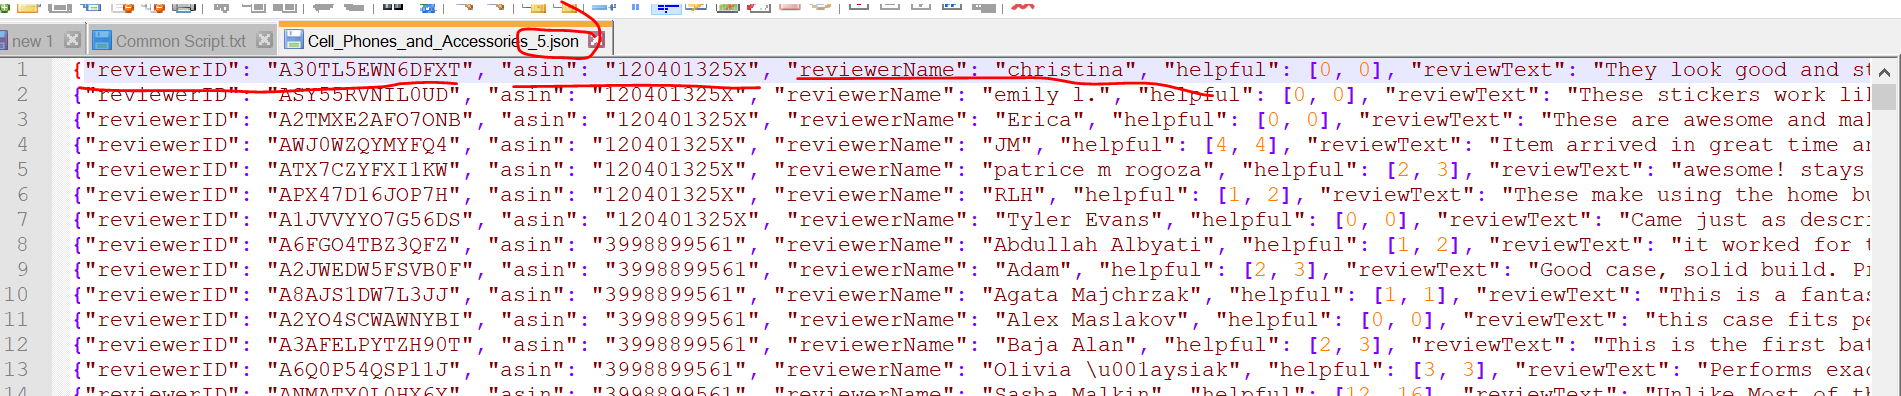

In [3]:
df = pd.read_json("Cell_Phones_and_Accessories_5.json", lines=True)
df

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A30TL5EWN6DFXT,120401325X,christina,"[0, 0]",They look good and stick good! I just don't li...,4,Looks Good,1400630400,"05 21, 2014"
1,ASY55RVNIL0UD,120401325X,emily l.,"[0, 0]",These stickers work like the review says they ...,5,Really great product.,1389657600,"01 14, 2014"
2,A2TMXE2AFO7ONB,120401325X,Erica,"[0, 0]",These are awesome and make my phone look so st...,5,LOVE LOVE LOVE,1403740800,"06 26, 2014"
3,AWJ0WZQYMYFQ4,120401325X,JM,"[4, 4]",Item arrived in great time and was in perfect ...,4,Cute!,1382313600,"10 21, 2013"
4,ATX7CZYFXI1KW,120401325X,patrice m rogoza,"[2, 3]","awesome! stays on, and looks great. can be use...",5,leopard home button sticker for iphone 4s,1359849600,"02 3, 2013"
...,...,...,...,...,...,...,...,...,...
194434,A1YMNTFLNDYQ1F,B00LORXVUE,eyeused2loveher,"[0, 0]",Works great just like my original one. I reall...,5,This works just perfect!,1405900800,"07 21, 2014"
194435,A15TX8B2L8B20S,B00LORXVUE,Jon Davidson,"[0, 0]",Great product. Great packaging. High quality a...,5,Great replacement cable. Apple certified,1405900800,"07 21, 2014"
194436,A3JI7QRZO1QG8X,B00LORXVUE,Joyce M. Davidson,"[0, 0]","This is a great cable, just as good as the mor...",5,Real quality,1405900800,"07 21, 2014"
194437,A1NHB2VC68YQNM,B00LORXVUE,Nurse Farrugia,"[0, 0]",I really like it becasue it works well with my...,5,I really like it becasue it works well with my...,1405814400,"07 20, 2014"


In [4]:
df.shape

(194439, 9)

> Here 194439 review records and 9 column, I this we need only reviewText coumn.

### Simple Preprocessing & Tokenization

- The first thing to do for any data science task is to clean the data. For NLP, we apply various processing like **converting all the words to lower case, trimming spaces, removing punctuations**. This is something we will do over here too.

- Additionally, we can also **remove stop words like 'and', 'or', 'is', 'the', 'a', 'an' and convert words to their root forms like 'running' to 'run'.**

In [5]:
gensim.utils.simple_preprocess("They look good and stick good! I just don't like ")

['they', 'look', 'good', 'and', 'stick', 'good', 'just', 'don', 'like']

In [6]:
#Apply this funct to all rows
review_text = df.reviewText.apply(gensim.utils.simple_preprocess)

> Here gensim.utils.simple_preprocess will do all preprocessing steps and each words split, lemmatization, Stopword removal, duplicate removalo list of words

In [7]:
review_text

0         [they, look, good, and, stick, good, just, don...
1         [these, stickers, work, like, the, review, say...
2         [these, are, awesome, and, make, my, phone, lo...
3         [item, arrived, in, great, time, and, was, in,...
4         [awesome, stays, on, and, looks, great, can, b...
                                ...                        
194434    [works, great, just, like, my, original, one, ...
194435    [great, product, great, packaging, high, quali...
194436    [this, is, great, cable, just, as, good, as, t...
194437    [really, like, it, becasue, it, works, well, w...
194438    [product, as, described, have, wasted, lot, of...
Name: reviewText, Length: 194439, dtype: object

In [8]:
df.reviewText.loc[0]
# Original data

"They look good and stick good! I just don't like the rounded shape because I was always bumping it and Siri kept popping up and it was irritating. I just won't buy a product like this again"

In [9]:
review_text.loc[0]

['they',
 'look',
 'good',
 'and',
 'stick',
 'good',
 'just',
 'don',
 'like',
 'the',
 'rounded',
 'shape',
 'because',
 'was',
 'always',
 'bumping',
 'it',
 'and',
 'siri',
 'kept',
 'popping',
 'up',
 'and',
 'it',
 'was',
 'irritating',
 'just',
 'won',
 'buy',
 'product',
 'like',
 'this',
 'again']

### Training the Word2Vec Model

- Train the model for reviews. Use a window of size 10 i.e. 10 words before the present word(Target word) and 10 words ahead of the present word(Target word). 

- A sentence with at least 2 words should only be considered, configure this using min_count parameter.

- Workers define how many CPU threads to be used.

##### Initialize the model gensim

In [10]:

model = gensim.models.Word2Vec(
    window=10,
    min_count=2,
    workers=4,
)

##### Build Vocabulary

- **Build Vocabulary** Means building list of unique words by using build_vocab function from gensim

- **progress_per** - after how many words to process before showing/updating the progress

In [11]:
"""sampletxt ="Hi my name Atharv my"
model.build_vocab(sampletxt, progress_per=1000)
model.corpus_count
#20
"""

'sampletxt ="Hi my name Atharv my"\nmodel.build_vocab(sampletxt, progress_per=1000)\nmodel.corpus_count\n#20\n'

In [12]:
model.build_vocab(review_text, progress_per=1000)

#### Default Epoch in model

In [13]:
model.epochs

5

In [14]:
model.corpus_count
# This built based on build_vocab function above, which tells 194439 unique word in full data

194439

##### Train the Word2Vec Model

- **total_examples** - is the total examples, which is corpus_count. Here its 194439 records, so train by passing all these records

In [15]:
model.train(review_text, total_examples=model.corpus_count, epochs=model.epochs)

(61507632, 83868975)

#### Save the Model
- Save the model so that it can be reused in other applications, deploy it in cloud etc

In [16]:
model.save("./word2vec-amazon-cell-accessories-reviews-short.model")

### Finding Similar Words and Similarity between words

- https://radimrehurek.com/gensim/models/word2vec.html

###### wv.most_similar

- In genism model we have function **Wv** word to vec with **most_similar**, it provides similarity words in whole datset

- Below it provides all words which are similar to **bad**

In [21]:
model.wv.most_similar("bad")

[('terrible', 0.6649450659751892),
 ('shabby', 0.6482768654823303),
 ('horrible', 0.598177969455719),
 ('good', 0.5855436325073242),
 ('disappointing', 0.5457225441932678),
 ('okay', 0.5410118103027344),
 ('upset', 0.5345655679702759),
 ('awful', 0.534559965133667),
 ('lame', 0.5330765247344971),
 ('mad', 0.5288878083229065)]

> Here good also came as similar, but its not, but it provided in the sense both are similar category bad, good 

###### wv.similarity
- Below it provides similarity value between 2 words


In [23]:
model.wv.similarity(w1="cheap", w2="inexpensive")

0.51575226

In [25]:
model.wv.similarity(w1="cheap", w2="cheap")

1.0

In [24]:
model.wv.similarity(w1="great", w2="good")

0.7804911

In [26]:
model.wv.similarity(w1="great", w2="product")

-0.047256153

In [27]:
model.wv.similarity(w1="great", w2="iphone")

0.08647418

### Further Reading

- You can read about gensim more at https://radimrehurek.com/gensim/models/word2vec.html

- Explore other Datasets related to Amazon Reviews: http://jmcauley.ucsd.edu/data/amazon/

### Exercise

- Train a word2vec model on the Sports & Outdoors Reviews Dataset Once you train a model on this, find the words most similar to 'awful' and find similarities between the following word tuples: ('good', 'great'), ('slow','steady')

- Click here for solution.